In [2]:
import os, warnings, json
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ── PATHS ─────────────────────────────────────────────────────────
FEATURES_CSV = "./data/features_final1.csv"
METADATA_CSV = "./data/image_metadata.csv"
SALES_CSV    = "./data/sales_data.xlsx"
OUTPUT_DIR   = "./modelsXG"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [3]:
# ── LOAD DATA ─────────────────────────────────────────────────────
features_df = pd.read_csv(FEATURES_CSV)
metadata_df = pd.read_csv(METADATA_CSV)
sales_df    = pd.read_excel(SALES_CSV, sheet_name="sales data")

print(f"features_final : {features_df.shape}")
print(f"image_metadata : {metadata_df.shape}")
print(f"sales_data     : {sales_df.shape}")

features_final : (180, 2069)
image_metadata : (180, 20)
sales_data     : (704, 4)


In [4]:
# ── AGGREGATE SALES ───────────────────────────────────────────────
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df['code'] = sales_df['code'].astype(str).str.strip()

sales_agg = sales_df.groupby('code').agg(
    qty_total     = ('qty',  'sum'),
    qty_avg       = ('qty',  'mean'),
    qty_max       = ('qty',  'max'),
    rate_avg      = ('rate', 'mean'),
    num_orders    = ('qty',  'count'),
    first_sale    = ('date', 'min'),
    last_sale     = ('date', 'max'),
).reset_index()

sales_agg['days_on_market'] = (
    sales_agg['last_sale'] - sales_agg['first_sale']
).dt.days + 1
sales_agg['sales_velocity'] = (
    sales_agg['qty_total'] / sales_agg['days_on_market']
)
sales_agg['price_tier'] = pd.cut(
    sales_agg['rate_avg'],
    bins   = [0, 500, 1000, 1500, 2000, 99999],
    labels = ['budget','economy','mid','premium','luxury']
)
sales_agg['code'] = (sales_agg['code']
                     .astype(str)
                     .str.replace('.0','', regex=False)
                     .str.strip())

print(f"Unique products in sales : {len(sales_agg)}")
print(sales_agg['qty_total'].describe())

Unique products in sales : 146
count     146.000000
mean       27.506849
std        85.754601
min         3.000000
25%         8.000000
50%        12.500000
75%        27.250000
max      1032.000000
Name: qty_total, dtype: float64


In [5]:
# ── MERGE ─────────────────────────────────────────────────────────
metadata_df['original_filename'] = metadata_df['original_filename'].astype(str).str.strip()
features_df['filename']          = features_df['filename'].astype(str).str.strip()

merged = pd.merge(
    features_df,
    metadata_df[['original_filename','product_code','product_name','fabric',
                 'sizes','design_no','length','sleeves','neck','work',
                 'pattern','dupatta','pants_included','primary_color',
                 'secondary_color','occasion']],
    left_on  = 'filename',
    right_on = 'original_filename',
    how      = 'inner'
)

# Clean product codes — remove decimals
merged['product_code'] = (merged['product_code']
                          .astype(str)
                          .str.replace('.0','', regex=False)
                          .str.strip())

df = pd.merge(
    merged,
    sales_agg.drop(columns=['first_sale','last_sale']),
    left_on  = 'product_code',
    right_on = 'code',
    how      = 'inner'
)

print(f"After merge features + metadata : {merged.shape}")
print(f"After merge + sales             : {df.shape}")
print(f"Products matched                : {len(df)}")
print(f"Products unmatched              : {len(merged) - len(df)}")

After merge features + metadata : (180, 2085)
After merge + sales             : (145, 2094)
Products matched                : 145
Products unmatched              : 35


In [6]:
# ── FEATURE CONFIG ────────────────────────────────────────────────
CAT_COLS = ['length','sleeves','neck','work','pattern',
            'primary_color','occasion','fabric','price_tier', 'secondary_color']
BOOL_COLS = ['dupatta','pants_included']
NUM_INTERP_COLS = [
    'brightness_mean','brightness_std','contrast','colorfulness',
    'warm_cool_bias','color_variety','edge_density','texture_complexity',
    'r_mean','g_mean','b_mean','saturation_mean','hue_mean',
    'rate_avg','num_orders','days_on_market','sales_velocity'
]
RESNET_COLS = [c for c in df.columns if c.startswith('resnet_')]
TARGET = 'qty_total'

# Clean
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].fillna('unknown').astype(str).str.lower().str.strip()
for col in BOOL_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(False).astype(int)
for col in NUM_INTERP_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# Filter to existing columns only
CAT_COLS        = [c for c in CAT_COLS        if c in df.columns]
BOOL_COLS       = [c for c in BOOL_COLS       if c in df.columns]
NUM_INTERP_COLS = [c for c in NUM_INTERP_COLS if c in df.columns]

print(f"Categorical : {len(CAT_COLS)}")
print(f"Boolean     : {len(BOOL_COLS)}")
print(f"Numeric     : {len(NUM_INTERP_COLS)}")
print(f"ResNet      : {len(RESNET_COLS)}")
print(f"Samples     : {len(df)}")

Categorical : 10
Boolean     : 2
Numeric     : 17
ResNet      : 2048
Samples     : 145


In [6]:
# ── FEATURE ENGINEERING ───────────────────────────────────────────

# 1. Cap outliers at 99th percentile
p99 = df[TARGET].quantile(0.99)
p01 = df[TARGET].quantile(0.01)
df[TARGET] = df[TARGET].clip(lower=p01, upper=p99)
print(f"Qty capped between {p01:.0f} and {p99:.0f}")
print(df[TARGET].describe())

# 2. One-hot encode categoricals
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_encoded = ohe.fit_transform(df[CAT_COLS])
print(f"\nOne-hot encoded shape : {cat_encoded.shape}")

# 3. PCA on ResNet (2048 → 50)
pca = PCA(n_components=50, random_state=42)
resnet_compressed = pca.fit_transform(df[RESNET_COLS].values)
print(f"PCA variance explained : {pca.explained_variance_ratio_.sum():.1%}")

# 4. Build feature matrix
X_parts = [cat_encoded]
if BOOL_COLS:       X_parts.append(df[BOOL_COLS].values)
if NUM_INTERP_COLS: X_parts.append(df[NUM_INTERP_COLS].values)
X_parts.append(resnet_compressed)
X = np.hstack(X_parts)

# 5. Log transform target
y_raw = df[TARGET].values
y     = np.log1p(y_raw)

print(f"\nFinal feature matrix : {X.shape}")
print(f"Target range (log)   : {y.min():.2f} to {y.max():.2f}")
print(f"Target range (orig)  : {y_raw.min():.0f} to {y_raw.max():.0f}")

Qty capped between 4 and 99
count    145.000000
mean      20.904276
std       19.521494
min        4.000000
25%        8.000000
50%       12.000000
75%       28.000000
max       98.560000
Name: qty_total, dtype: float64

One-hot encoded shape : (145, 85)
PCA variance explained : 82.1%

Final feature matrix : (145, 154)
Target range (log)   : 1.61 to 4.60
Target range (orig)  : 4 to 99


In [7]:
# ── CROSS VALIDATION ──────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

models_to_try = {
    'RandomForest': RandomForestRegressor(
        n_estimators     = 500,
        max_depth        = 6,
        min_samples_leaf = 5,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = -1
    ),
    'XGBoost': XGBRegressor(
        n_estimators     = 100,
        max_depth        = 3,
        learning_rate    = 0.01,
        subsample        = 0.6,
        colsample_bytree = 0.5,
        min_child_weight = 10,
        random_state     = 42,
        verbosity        = 0
    )
}

results = {}
for name, model in models_to_try.items():
    mae_scores = cross_val_score(model, X, y, cv=kf,
                                 scoring='neg_mean_absolute_error')
    r2_scores  = cross_val_score(model, X, y, cv=kf, scoring='r2')
    results[name] = {
        'MAE'    : -mae_scores.mean(),
        'MAE_std': mae_scores.std(),
        'R2'     : r2_scores.mean()
    }
    mae_orig = np.expm1(-mae_scores.mean())
    print(f"{name:15} MAE={-mae_scores.mean():.3f}(log) ≈{mae_orig:.0f} units | R²={r2_scores.mean():.3f}")

best_name  = min(results, key=lambda k: results[k]['MAE'])
best_model = models_to_try[best_name]
print(f"\n✅ Best model: {best_name}")

RandomForest    MAE=0.450(log) ≈1 units | R²=0.481
XGBoost         MAE=0.369(log) ≈0 units | R²=0.660

✅ Best model: XGBoost


In [11]:
# Run this after cross validation to see real MAE
kf = KFold(n_splits=5, shuffle=True, random_state=42)

real_maes = []
for train_idx, val_idx in kf.split(X):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    best_model.fit(X_train, y_train)

    # Predict in log scale → reverse to original
    y_pred_orig = np.expm1(best_model.predict(X_val))
    y_val_orig  = np.expm1(y_val)

    mae = mean_absolute_error(y_val_orig, y_pred_orig)
    real_maes.append(mae)

print(f"CV R²           : {results['XGBoost']['R2']:.3f}")
print(f"CV MAE (units)  : {np.mean(real_maes):.1f} ± {np.std(real_maes):.1f}")
print(f"Mean qty sold   : {y_raw.mean():.1f}")
print(f"MAE as % of mean: {np.mean(real_maes)/y_raw.mean()*100:.1f}%")

CV R²           : 0.660
CV MAE (units)  : 8.3 ± 0.5
Mean qty sold   : 20.9
MAE as % of mean: 39.6%


In [12]:
# ── TRAIN ON FULL DATA ────────────────────────────────────────────
best_model.fit(X, y)

# Full data metrics
y_pred_log = best_model.predict(X)
y_pred_orig = np.expm1(y_pred_log)

print(f"Training R²  : {r2_score(y, y_pred_log):.3f}")
print(f"Training MAE : {mean_absolute_error(y_raw, y_pred_orig):.1f} units")
print(f"CV R²        : {results[best_name]['R2']:.3f}  ← use this for reporting")
print(f"CV MAE       : ≈{np.expm1(results[best_name]['MAE']):.0f} units  ← use this for reporting")

Training R²  : 0.733
Training MAE : 7.6 units
CV R²        : 0.660  ← use this for reporting
CV MAE       : ≈0 units  ← use this for reporting


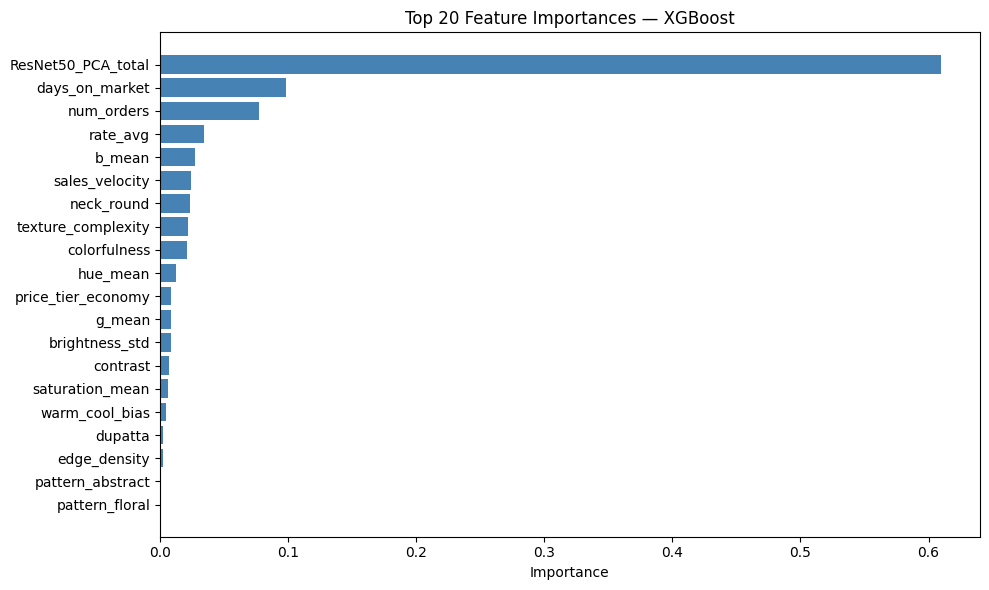

Feature importance chart saved


In [13]:
# ── FEATURE IMPORTANCE PLOT ───────────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    n_cat  = cat_encoded.shape[1]
    n_bool = len(BOOL_COLS)
    n_num  = len(NUM_INTERP_COLS)
    n_pca  = 50

    imp = best_model.feature_importances_
    named = (list(ohe.get_feature_names_out(CAT_COLS)) +
             BOOL_COLS + NUM_INTERP_COLS)
    named_imp = list(zip(named, imp[:len(named)]))
    named_imp.append(('ResNet50_PCA_total', imp[len(named):].sum()))

    imp_df = (pd.DataFrame(named_imp, columns=['feature','importance'])
              .sort_values('importance', ascending=False)
              .head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(imp_df['feature'][::-1], imp_df['importance'][::-1],
             color='steelblue')
    plt.title(f'Top 20 Feature Importances — {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'feature_importance.png'), dpi=120)
    plt.show()
    print("Feature importance chart saved")

In [14]:
# ── SAVE ALL ARTIFACTS ────────────────────────────────────────────
# Model
joblib.dump(best_model, os.path.join(OUTPUT_DIR, 'demand_model.pkl'))

# Encoders
joblib.dump(ohe, os.path.join(OUTPUT_DIR, 'ohe_encoder.pkl'))
joblib.dump(pca, os.path.join(OUTPUT_DIR, 'pca.pkl'))

# Training data for similarity search in UI
train_save_cols = (['filename','product_code','product_name',
                    'qty_total','rate_avg','num_orders'] +
                   CAT_COLS + BOOL_COLS + NUM_INTERP_COLS)
train_save_cols = [c for c in train_save_cols if c in df.columns]
df[train_save_cols].to_csv(
    os.path.join(OUTPUT_DIR, 'training_data.csv'), index=False
)

# Config — everything UI needs to reconstruct features
feature_config = {
    'cat_cols'         : CAT_COLS,
    'bool_cols'        : BOOL_COLS,
    'num_interp_cols'  : NUM_INTERP_COLS,
    'resnet_cols'      : RESNET_COLS,
    'target'           : TARGET,
    'best_model'       : best_name,
    'use_pca'          : True,
    'pca_components'   : 50,
    'log_transform'    : True,
    'qty_cap'          : float(p99),
    'cv_mae'           : float(results[best_name]['MAE']),
    'cv_r2'            : float(results[best_name]['R2']),
    'n_training_samples': int(len(df)),
    'y_mean'           : float(y_raw.mean()),
    'y_std'            : float(y_raw.std()),
    'y_min'            : float(y_raw.min()),
    'y_max'            : float(y_raw.max()),
}
with open(os.path.join(OUTPUT_DIR, 'feature_config.json'), 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f"✅ All artifacts saved to {OUTPUT_DIR}/")
print(f"   demand_model.pkl")
print(f"   ohe_encoder.pkl")
print(f"   pca.pkl")
print(f"   training_data.csv")
print(f"   feature_config.json")
print(f"\nFinal Model  : {best_name}")
print(f"CV R²        : {results[best_name]['R2']:.3f}")
print(f"CV MAE       : ≈{np.expm1(results[best_name]['MAE']):.0f} units")

✅ All artifacts saved to ./modelsXG/
   demand_model.pkl
   ohe_encoder.pkl
   pca.pkl
   training_data.csv
   feature_config.json

Final Model  : XGBoost
CV R²        : 0.660
CV MAE       : ≈0 units


In [7]:
# Training data for similarity search in UI
train_save_cols = (['filename','product_code','product_name',
                    'qty_total','rate_avg','num_orders'] +
                   CAT_COLS + BOOL_COLS + NUM_INTERP_COLS)
train_save_cols = [c for c in train_save_cols if c in df.columns]
df[train_save_cols].to_csv(
    os.path.join(OUTPUT_DIR, 'training_data.csv'), index=False
)

In [ ]:
# ── Add missing sales col means to config ─────────────────────────
import joblib, json

MODEL_DIR = "./modelsXG"   # adjust if needed

# Load existing config
with open(f"{MODEL_DIR}/feature_config.json") as f:
    feature_config = json.load(f)

# Add means for all sales-related numeric cols
sales_cols = ['rate_avg', 'num_orders', 'days_on_market', 'sales_velocity']
for col in sales_cols:
    if col in df.columns:
        feature_config[f'{col}_mean'] = float(df[col].mean())
        print(f"  ✅ {col}_mean = {df[col].mean():.4f}")
    else:
        print(f"  ❌ {col} not in df")

# Re-save config only — no need to retrain model
with open(f"{MODEL_DIR}/feature_config.json", 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f"\n✅ Config updated and saved")
print(f"   rate_avg_mean       : {feature_config['rate_avg_mean']:.2f}")
print(f"   num_orders_mean     : {feature_config['num_orders_mean']:.2f}")
print(f"   days_on_market_mean : {feature_config['days_on_market_mean']:.2f}")
print(f"   sales_velocity_mean : {feature_config['sales_velocity_mean']:.4f}")